### Smartphone Price Prediction Mdoel

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Sales.csv')
df.head()

,Brands,Models,Colors,Memory,Storage,Camera,Rating,Selling Price,Original Price,Mobile,Discount,discount percentage
0,SAMSUNG,GALAXY M31S,Mirage Black,8 GB,128 GB,Yes,4.3,19330,20999,SAMSUNG GALAXY M31S,1669,7.947998
1,Nokia,3.2,Steel,2 GB,16 GB,Yes,3.8,10199,10199,Nokia 3.2,0,0.000000
2,realme,C2,Diamond Black,2 GB,NaN,Yes,4.4,6999,7999,realme C2,1000,12.501563
3,Infinix,Note 5,Ice Blue,4 GB,64 GB,Yes,4.2,12999,12999,Infinix Note 5,0,0.000000
4,Apple,iPhone 11,Black,4GB,64 GB,Yes,4.6,49900,49900,Apple iPhone 11,0,0.000000


## Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3114 entries, 0 to 3113
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brands               3114 non-null   object 
 1   Models               3114 non-null   object 
 2   Colors               3114 non-null   object 
 3   Memory               3071 non-null   object 
 4   Storage              3075 non-null   object 
 5   Camera               3114 non-null   object 
 6   Rating               2970 non-null   float64
 7   Selling Price        3114 non-null   int64  
 8   Original Price       3114 non-null   int64  
 9   Mobile               3114 non-null   object 
 10  Discount             3114 non-null   int64  
 11  discount percentage  3114 non-null   float64
dtypes: float64(2), int64(3), object(7)
memory usage: 292.1+ KB


In [5]:
df.describe()

,Rating,Selling Price,Original Price,Discount,discount percentage
count,2970.000000,3114.000000,3114.000000,3114.000000,3114.000000
mean,4.243098,26436.625562,28333.473025,1896.847463,6.086788
std,0.271991,30066.892622,31525.599889,5337.126176,11.106776
min,2.300000,1000.000000,1000.000000,-8000.000000,-160.320641
25%,4.100000,9990.000000,10030.250000,0.000000,0.000000
50%,4.300000,15000.000000,16889.500000,0.000000,0.000000
75%,4.400000,28999.000000,31500.000000,2000.000000,9.836388
max,5.000000,179900.000000,189999.000000,75000.000000,70.610305


In [6]:
df.duplicated().sum()

np.int64(108)

In [7]:
df.drop_duplicates(keep='first', inplace= True)

In [8]:
df['Camera'].value_counts()

Camera
Yes    3006
Name: count, dtype: int64

In [9]:
## This means every phone has camera


df = df.drop(columns = ['Models', 'Camera'])
df.head()

,Brands,Colors,Memory,Storage,Rating,Selling Price,Original Price,Mobile,Discount,discount percentage
0,SAMSUNG,Mirage Black,8 GB,128 GB,4.3,19330,20999,SAMSUNG GALAXY M31S,1669,7.947998
1,Nokia,Steel,2 GB,16 GB,3.8,10199,10199,Nokia 3.2,0,0.000000
2,realme,Diamond Black,2 GB,NaN,4.4,6999,7999,realme C2,1000,12.501563
3,Infinix,Ice Blue,4 GB,64 GB,4.2,12999,12999,Infinix Note 5,0,0.000000
4,Apple,Black,4GB,64 GB,4.6,49900,49900,Apple iPhone 11,0,0.000000


In [10]:
df.shape

(3006, 10)

In [11]:
df.columns

Index(['Brands', 'Colors', 'Memory', 'Storage', 'Rating', 'Selling Price',
       'Original Price', 'Mobile', 'Discount', 'discount percentage'],
      dtype='object')

In [12]:
df.isnull().sum()

Brands                   0
Colors                   0
Memory                  40
Storage                 39
Rating                 130
Selling Price            0
Original Price           0
Mobile                   0
Discount                 0
discount percentage      0
dtype: int64

In [13]:
df['Rating'].fillna(df['Rating'].mean(), inplace = True)
df.head()

,Brands,Colors,Memory,Storage,Rating,Selling Price,Original Price,Mobile,Discount,discount percentage
0,SAMSUNG,Mirage Black,8 GB,128 GB,4.3,19330,20999,SAMSUNG GALAXY M31S,1669,7.947998
1,Nokia,Steel,2 GB,16 GB,3.8,10199,10199,Nokia 3.2,0,0.000000
2,realme,Diamond Black,2 GB,NaN,4.4,6999,7999,realme C2,1000,12.501563
3,Infinix,Ice Blue,4 GB,64 GB,4.2,12999,12999,Infinix Note 5,0,0.000000
4,Apple,Black,4GB,64 GB,4.6,49900,49900,Apple iPhone 11,0,0.000000


In [14]:
df.dropna(inplace = True)

In [15]:
df['Memory'].value_counts()

Memory
4 GB      726
6 GB      483
3 GB      467
2 GB      362
8 GB      336
1 GB      191
4GB       113
12 GB      58
512 MB     46
4 MB       39
1.5 GB     29
16 MB      15
32 MB      14
64 MB      14
8 MB       10
768 MB      6
128 MB      4
10 MB       3
2 MB        2
18 GB       2
46 MB       2
16 GB       2
153 MB      1
30 MB       1
100 MB      1
Name: count, dtype: int64

In [16]:
df['Memory'] = df['Memory'].replace('4GB', '4 GB')

## Memory Distribution

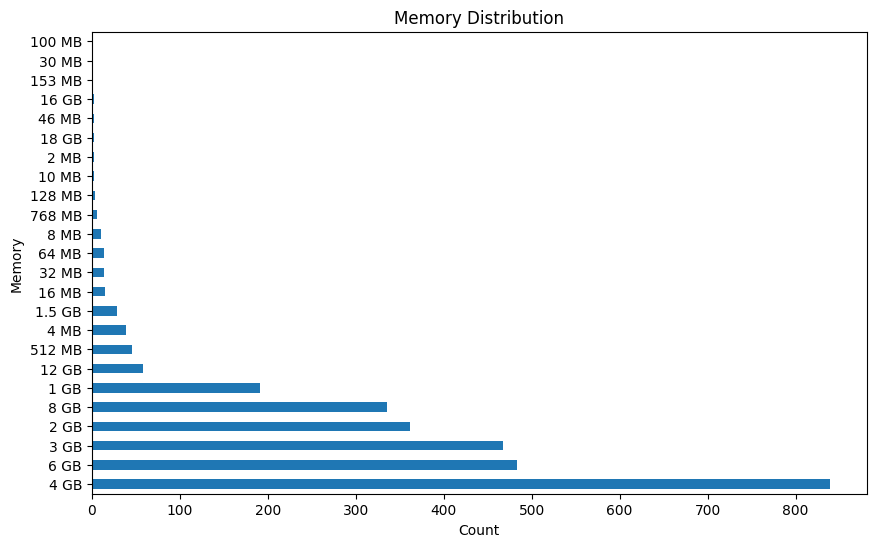

In [17]:
plt.figure(figsize = (10,6))

df['Memory'].value_counts().plot(kind= 'barh')

plt.title('Memory Distribution')
plt.xlabel('Count')
plt.ylabel('Memory')
plt.show()

In [18]:
invalid_memory = ['768 MB', '128 MB', '10 MB', '2 MB', '46 MB', '18 GB', '16 GB', '153 MB', '30 MB', '100 MB','8 MB','32 MB', '16 MB','4 MB','64 MB']

df = df[~df['Memory'].isin(invalid_memory)]

In [19]:
df['Memory'].value_counts()

Memory
4 GB      839
6 GB      483
3 GB      467
2 GB      362
8 GB      336
1 GB      191
12 GB      58
512 MB     46
1.5 GB     29
Name: count, dtype: int64

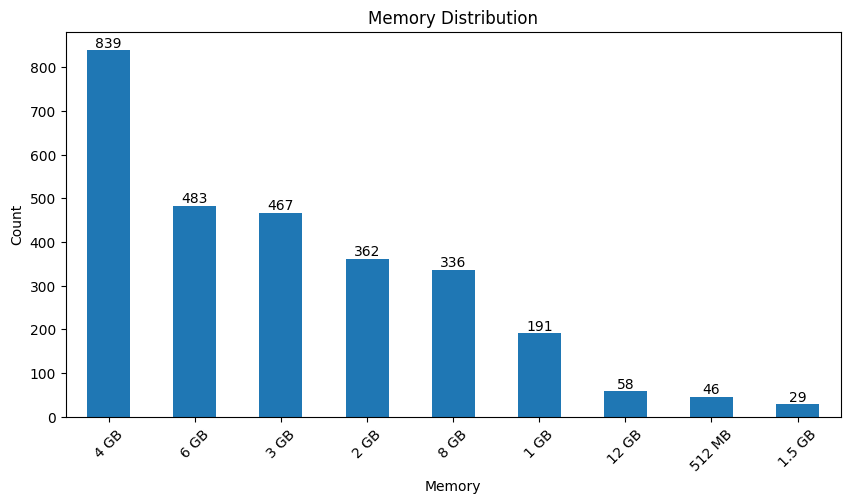

In [20]:
plt.figure(figsize = (10,5))
ax = df['Memory'].value_counts().sort_values(ascending = False).plot(kind = 'bar')
plt.title('Memory Distribution')
plt.xlabel('Memory')
plt.xticks(rotation = 45)
plt.ylabel('Count')


for i , v in enumerate(df['Memory'].value_counts()):
    ax.text(i , v+ 0.1, str(v), ha = 'center', va = 'bottom')

plt.show()


In [21]:
df['Storage'].value_counts()

Storage
64 GB                    749
128 GB                   736
32 GB                    539
16 GB                    312
256 GB                   213
8 GB                     133
512 GB                    53
4 GB                      50
1 TB                      14
129 GB                     3
512 MB                     2
130 GB                     2
2 MB                       2
Expandable Upto 32 GB      1
256 MB                     1
140 MB                     1
Name: count, dtype: int64

In [22]:
invalid_storage = ['Expandable Upto 32 GB', 'Expandable Upto 16 GB', '8 MB', '256 MB', '129 GB', '130 GB', '64 MB', '512 MB', '10 MB', '100 MB', '140 MB', '2 MB']

df = df[~df['Storage'].isin(invalid_storage)]
df['Storage'].value_counts()

Storage
64 GB     749
128 GB    736
32 GB     539
16 GB     312
256 GB    213
8 GB      133
512 GB     53
4 GB       50
1 TB       14
Name: count, dtype: int64

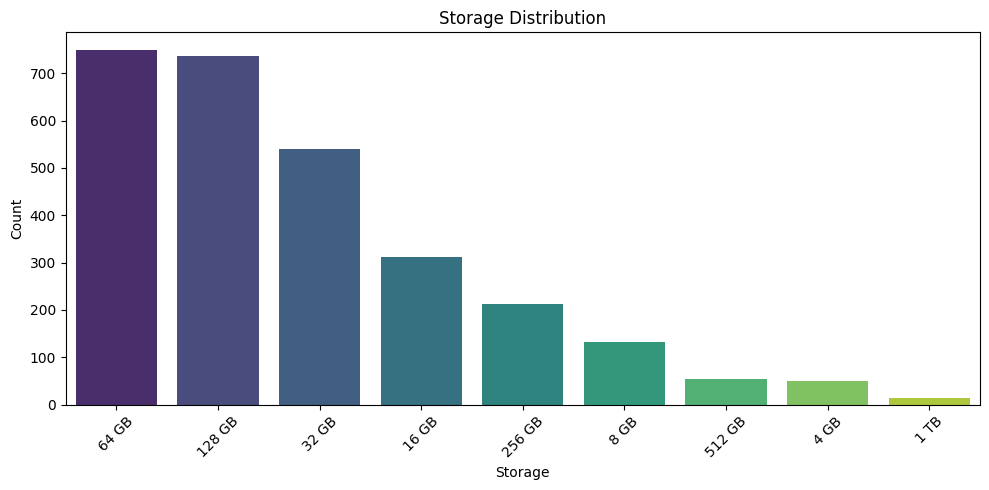

In [23]:
plt.figure(figsize = (10,5))
sns.countplot(
    data = df,
    x = 'Storage',
    order = df['Storage'].value_counts().index,
    palette = 'viridis'
)
plt.title('Storage Distribution')
plt.xlabel('Storage')
plt.xticks(rotation = 45)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [24]:
df['Colors'].value_counts()

Colors
Black                    330
Gold                     182
White                    142
Blue                     134
Silver                    93
                        ... 
Volcanic Grey              1
Astro Moonlight White      1
Fiery Red                  1
Aurora Grey                1
Sapphire Gradient          1
Name: count, Length: 636, dtype: int64

- Since all brand give thier smarphone their unique color name , we can drop that column

In [25]:
df = df.drop(columns = ['Colors'])

In [26]:
df.columns

Index(['Brands', 'Memory', 'Storage', 'Rating', 'Selling Price',
       'Original Price', 'Mobile', 'Discount', 'discount percentage'],
      dtype='object')

In [27]:
df['Mobile'].value_counts()

Mobile
Apple iPhone 13 Pro Max    19
Apple iPhone 11            19
Apple iPhone 12            18
Apple iPhone 12 Mini       18
SAMSUNG Galaxy A12         18
                           ..
GIONEE Ctrl V4S             1
GIONEE Elife S5.1           1
SAMSUNG GALAXY M31S         1
GIONEE Elife E8             1
Apple iPhone 13 Pro         1
Name: count, Length: 848, dtype: int64

- Every Brands has different model and mobile, different memory and storage combination , So also only Keeping the Brands ..and there memory and storage combinations price

In [28]:
df = df.drop(columns = ['Mobile'])

In [29]:
df.columns

Index(['Brands', 'Memory', 'Storage', 'Rating', 'Selling Price',
       'Original Price', 'Discount', 'discount percentage'],
      dtype='object')

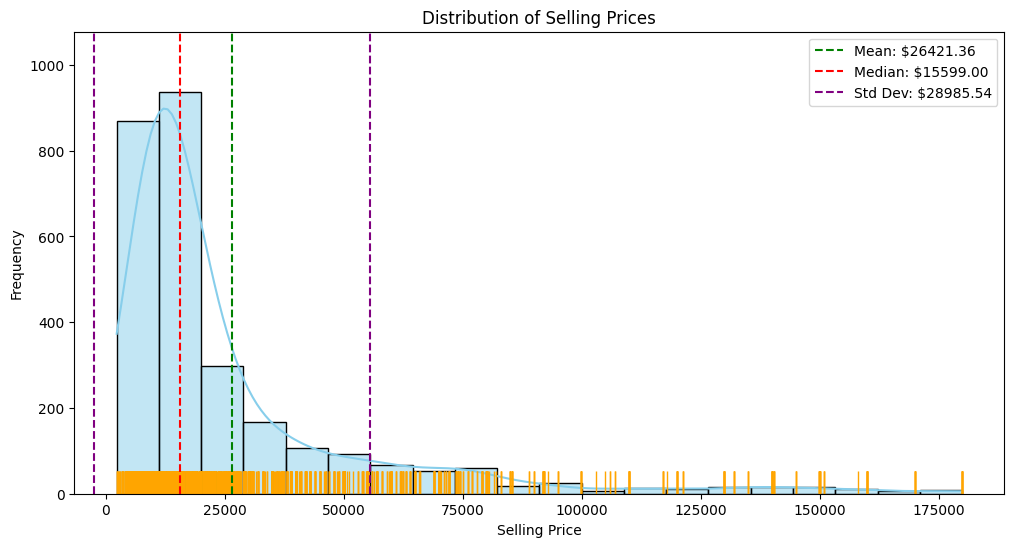

In [30]:
plt.figure(figsize=(12, 6))

sns.histplot(df['Selling Price'], bins=20, kde=True, color='skyblue')

plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.title('Distribution of Selling Prices')

sns.rugplot(
    df['Selling Price'],
    color='orange',
    height=0.05
        )

# Add summary statistics (mean, median, and standard deviation)
mean_original_price = df['Selling Price'].mean()
median_original_price = df['Selling Price'].median()
std_original_price = df['Selling Price'].std()


plt.axvline(
    mean_original_price,
    color='green', 
    linestyle='--', 
    label=f'Mean: ${mean_original_price:.2f}'
    )

plt.axvline(
    median_original_price, 
    color='red', 
    linestyle='--', 
    label=f'Median: ${median_original_price:.2f}'
    )

plt.axvline(
    mean_original_price + std_original_price, 
    color='purple', 
    linestyle='--', 
    label=f'Std Dev: ${std_original_price:.2f}'
    )

plt.axvline(
    mean_original_price - std_original_price, 
    color='purple', 
    linestyle='--'
    )

plt.legend()
plt.show()

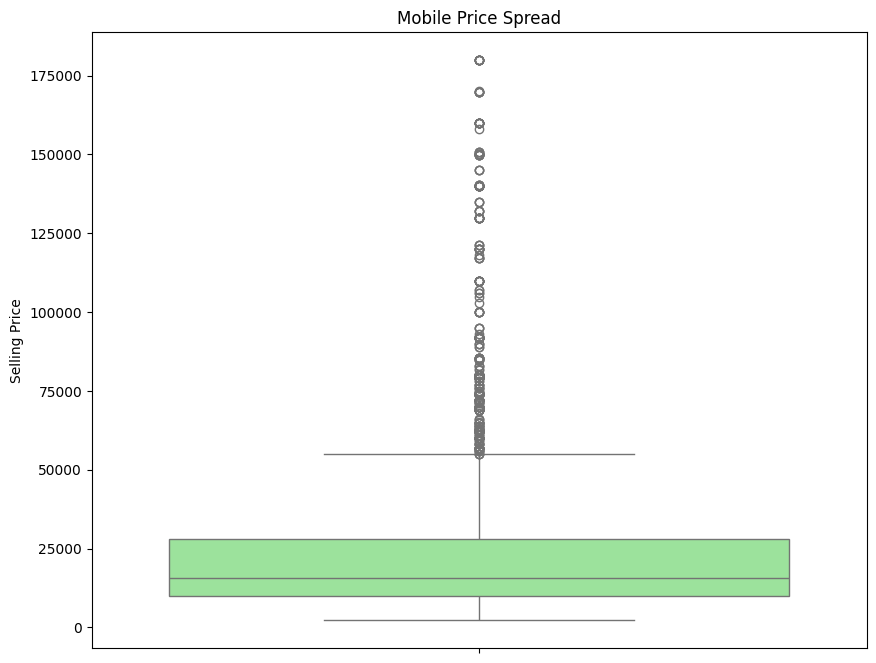

In [31]:
plt.figure(figsize = (10,8))
plt.title('Mobile Price Spread')

sns.boxplot(
    y = df['Selling Price'],
    color = 'lightgreen',
    width  = 0.8,
    orient= 'v'
)
plt.ylabel('Selling Price')
plt.show()


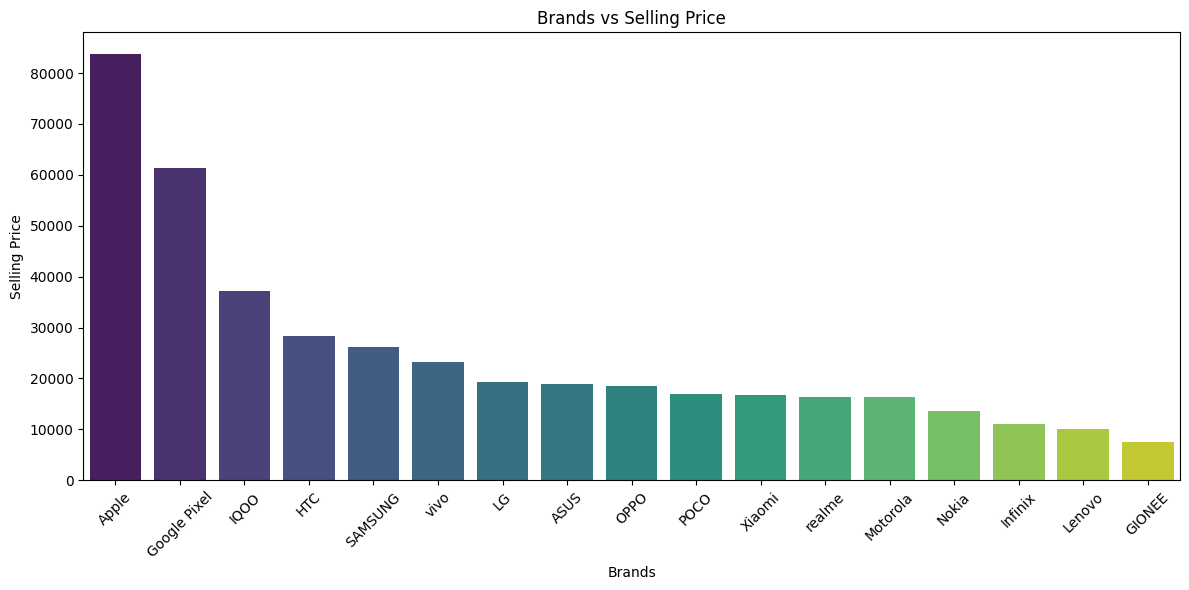

In [32]:
# Barnd v\s selling Price Analysis

plt.figure(figsize=(12, 6))
sns.barplot(
    data = df,
    x = 'Brands',
    y = 'Selling Price',
    order = df.groupby('Brands')['Selling Price'].mean().sort_values(ascending=False).index,
    ci = None,
    palette = 'viridis'
)
plt.xlabel('Brands')
plt.ylabel('Selling Price')
plt.title('Brands vs Selling Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

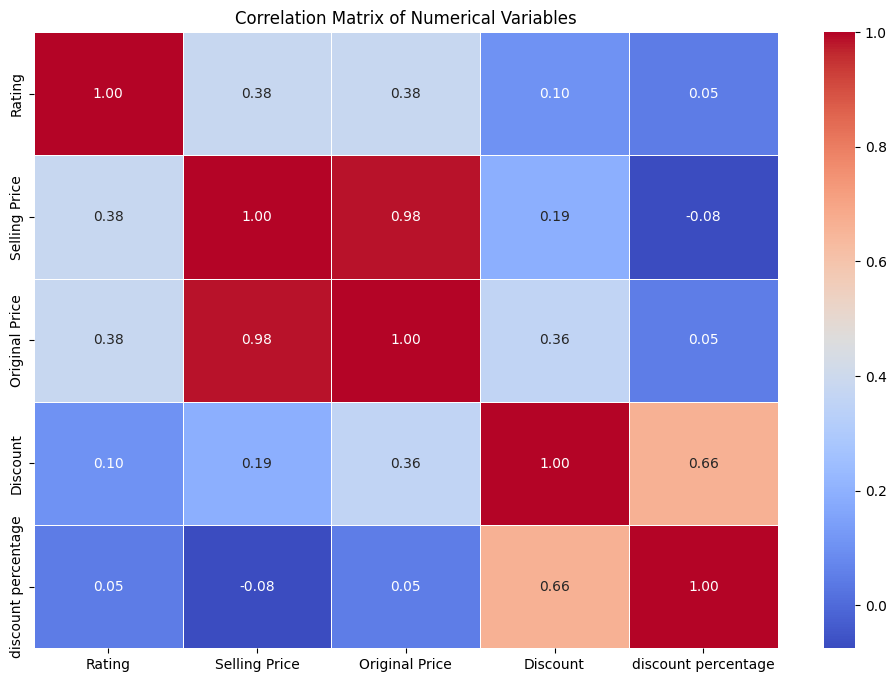

In [33]:
numerical_df = df.select_dtypes(include = ['float64','int64'])

correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = 'coolwarm',
    fmt= ".2f",
    linewidths= 0.5,
)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

- We can see that Original Price and the Selling Price is Highly correlated, So I am Keeping one

In [34]:
df = df.drop(columns = ['Original Price'])

# Encode categorical Variables

In [35]:
df['Memory'].value_counts()

Memory
4 GB      839
6 GB      481
3 GB      467
2 GB      362
8 GB      332
1 GB      191
12 GB      58
512 MB     40
1.5 GB     29
Name: count, dtype: int64

In [36]:
memory_hiearchy = {

    '4 GB': 4,
    '6 GB': 3,
    '3 GB': 5,
    '2 GB': 6,
    '8 GB': 2,
    '1 GB': 8,
    '12 GB': 1,
    '512 MB': 8,
    '1.5 GB': 7
    
}
df['Memory'] = df['Memory'].map(memory_hiearchy)
df.head()

,Brands,Memory,Storage,Rating,Selling Price,Discount,discount percentage
0,SAMSUNG,2,128 GB,4.300000,19330,1669,7.947998
1,Nokia,6,16 GB,3.800000,10199,0,0.000000
3,Infinix,4,64 GB,4.200000,12999,0,0.000000
4,Apple,4,64 GB,4.600000,49900,0,0.000000
6,Apple,3,512 GB,4.236057,99900,0,0.000000


In [37]:
df['Storage'].value_counts()

Storage
64 GB     749
128 GB    736
32 GB     539
16 GB     312
256 GB    213
8 GB      133
512 GB     53
4 GB       50
1 TB       14
Name: count, dtype: int64

In [38]:
df['Storage'].value_counts()

Storage
64 GB     749
128 GB    736
32 GB     539
16 GB     312
256 GB    213
8 GB      133
512 GB     53
4 GB       50
1 TB       14
Name: count, dtype: int64

In [39]:
Storage_hierarchy = {
    '1 TB': 1,
    '512 GB': 2,
    '256 GB': 3,
    '128 GB': 4,
    '64 GB': 5,
    '32 GB': 6,
    '16 GB': 7,
    '8 GB': 8,
    '4 GB': 9,
    '128 MB': 10,
    '4 MB': 11
}

df['Storage'] = df['Storage'].map(Storage_hierarchy)

df.head()

,Brands,Memory,Storage,Rating,Selling Price,Discount,discount percentage
0,SAMSUNG,2,4,4.300000,19330,1669,7.947998
1,Nokia,6,7,3.800000,10199,0,0.000000
3,Infinix,4,5,4.200000,12999,0,0.000000
4,Apple,4,5,4.600000,49900,0,0.000000
6,Apple,3,2,4.236057,99900,0,0.000000


In [49]:
df.info()
df['Selling Price'].max()
df['Selling Price'].min()

<class 'pandas.core.frame.DataFrame'>
Index: 2799 entries, 0 to 3113
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brands               2799 non-null   object 
 1   Memory               2799 non-null   int64  
 2   Storage              2799 non-null   int64  
 3   Rating               2799 non-null   float64
 4   Selling Price        2799 non-null   int64  
 5   Discount             2799 non-null   int64  
 6   discount percentage  2799 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 174.9+ KB


np.int64(2290)

In [44]:
import plotly.express as px 
import plotly

In [52]:
fig = px.bar(
    df,
    x = 'Brands',
    y = 'Selling Price',
    color = 'Brands',
    animation_frame= 'Rating',
    animation_group= 'Brands',
    range_y= [1000, 200000]
)
plotly.offline.plot(fig, 'bar.html')

'temp-plot.html'